# Библиотеки

In [1]:
from itertools import combinations
from pprint import pprint

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import statsmodels.stats.stattools as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import add_constant

import seaborn as sns

## 10.13 Квантильная регрессия (библиотека statsmodels)

- `Продуктивность` - обобщенная оценка продуктивности студента преподавателями всех предметов
- `Пр_оценка` - преобразованный средний бал оценок по всем предметам
- `Интерес` - оценка интереса студента к профпредмету
- `Оц_сокурс` - социометрическая оценка студента его сокурсниками по типу «пошел/не пошел бы с ним в разведку»
- `Пол` - пол М или Ж. Это номинальная категориальная переменная, закодирована текстовыми значениями, но могла бы быть закодирована 0 и 1 или 1 и 2 ведь цифры в ней ничего не значат\не имеют математического смысла, а просто являются кодами смысловых категорий\названий.

In [3]:
d = pd.read_spss('./data/SPSS25.sav')

In [4]:
d.dtypes

Продуктивность     float64
Пр_оценка          float64
Интерес            float64
Оц_сокурс          float64
Пол               category
dtype: object

In [6]:
d.head()

,Продуктивность,Пр_оценка,Интерес,Оц_сокурс,Пол
0,32.000000,6.125,6.0,1.666667,жен
1,32.256546,1.625,4.0,6.333333,жен
2,37.882654,4.500,2.0,3.666667,жен
3,58.094772,2.375,4.0,3.666667,жен
4,26.739992,5.125,5.5,3.666667,муж


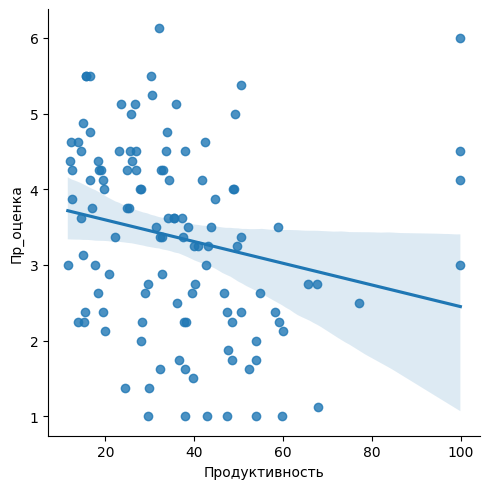

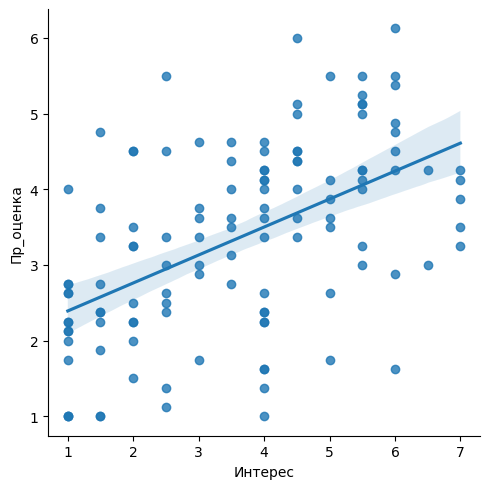

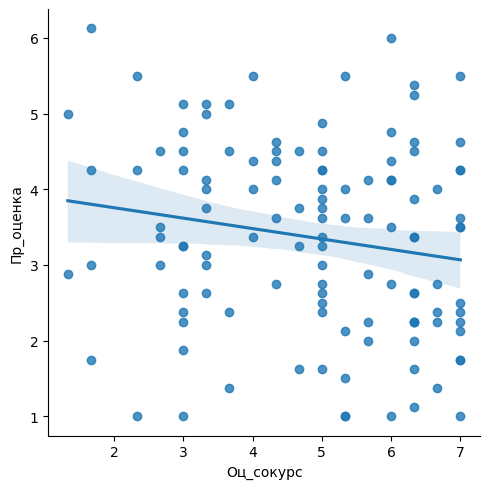

In [10]:
for x in ['Продуктивность', 'Интерес', 'Оц_сокурс']:
    sns.lmplot(data=d, x=x, y='Пр_оценка')

In [7]:
model=smf.quantreg(formula='Пр_оценка~Продуктивность+Интерес+Оц_сокурс+C(Пол)', data=d)
res=model.fit(q=0.5)

In [8]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:              Пр_оценка   Pseudo R-squared:               0.2142
Model:                       QuantReg   Bandwidth:                       1.046
Method:                 Least Squares   Sparsity:                        2.715
Date:                Sun, 04 Jan 2026   No. Observations:                  120
Time:                        16:49:00   Df Residuals:                      115
                                        Df Model:                            4
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.6121      0.594      4.394      0.000       1.435       3.790
C(Пол)[T.муж]      0.3629      0.315      1.153      0.251      -0.261       0.987
Продуктивность    -0.0078      0.007     -1.142      0.256      -0.021       0.006
Интерес            0.3609      0.073      4.953      0.000       0.217       0.505
Оц_сокурс         -0.0552      0.082     -0.675      0.501      -0.217       0.107
==================================================================================
"""

In [13]:
# 0.4-0.6 нормально, а более 0.6
res.prsquared

np.float64(0.21423176974558356)

In [11]:
pd.DataFrame({'Q': res.params, 'Qp': res.pvalues})

,Q,Qp
Intercept,2.612091,0.000025
C(Пол)[T.муж],0.362938,0.251393
Продуктивность,-0.007751,0.255976
Интерес,0.360915,0.000003
Оц_сокурс,-0.055192,0.501256


In [19]:
quantiles = [0.25, 0.5, 0.75] # квантили
model_stats = [] # пустые списки для записи результатов из цикла
coef_rows = []
pval_rows = []

for q in quantiles: # перебор квантилей из списка и их поочередная запись в q
    resC = model.fit(q=q)  # поочередное обучение созданной ранее спецификации модели model на каждом q - и запись результата в resC
    model_stats.append(resC.prsquared) # добавление в соотв. список псевдо-R2 из каждой итерации
    coef_rows.append(resC.params) # добавление в соотв. список коэффициентов предикторов из каждой итерации
    pval_rows.append(resC.pvalues) # добавление в соотв. список pval для предикторов из каждой итерации

MQ = pd.DataFrame(model_stats) # формирование датафреймов из списков
MQ.index = [0.25,0.5,0.75]

Coef = pd.DataFrame(coef_rows)
Pval = pd.DataFrame(pval_rows)

In [20]:
MQ

,0
0.25,0.161005
0.50,0.214232
0.75,0.197669


In [16]:
Coef

,Intercept,C(Пол)[T.муж],Продуктивность,Интерес,Оц_сокурс
0,2.225915,0.039048,-0.016465,0.352276,-0.032351
1,2.612091,0.362938,-0.007751,0.360915,-0.055192
2,4.152330,0.169908,-0.010518,0.333574,-0.204723


In [17]:
Pval

,Intercept,C(Пол)[T.муж],Продуктивность,Интерес,Оц_сокурс
0,1.220551e-03,0.913093,0.024349,0.000198,0.742086
1,2.490977e-05,0.251393,0.255976,0.000003,0.501256
2,2.653544e-11,0.572104,0.126573,0.000001,0.007309
